# <center> Практические задания по цифровой обработке сигналов </center>
# <center> Первая лабораторная работа </center>


В данной работе Вы познакомитесь с основными методами работы с аудиоданными в Python. Разбересь в том, как работает свертка, и примените пару интересных фильтров.

# Задание 1. Работа с аудиофайлами в Python (1 балл)

## Теория

Звук - это аналоговый сигнал. То есть он является непрерывным по времени и по значениям. Для того, чтобы работать со звуком на цифровом устройстве, надо преобразовать его в цифровое представление. Для этого надо разделить непрерывный сигнал на промежутки времени (дискретизация сигнала) и разбить непрерывные значения на интервалы (квантование сигнала). Выбраные параметры дискретизации и квантования сигнала напрямую влияют на качество цифрового сигнала. 

<!-- 
## Практика

1. Что хранится в .wav файле? Как узнать параметры дискретизации и квантования .wav файла? 

2. Запишите аудиофайл со своим голосом. Загрузите его. Попробуйте поменять ему частоту дискретизации. Нарисуйте форму волны считанного файла. Воспроизведите полученные сигналы. При какой частоте дискретизации становится невозможно разобрать человеческую речь?   

3. Чем .wav отличается от других кодеков, например .mp3 или .ogg? -->


<!-- ### Подсказка

Записать цифровой сигнал можно при помощи, например, [Audacity](https://www.audacityteam.org) или [Adobe Audition](https://www.adobe.com/ru/products/audition.html). Для считывания файлов воспользуйтесь библиотекой [scipy](https://www.scipy.org) или [librosa](https://librosa.org/doc/latest/index.html). Для воспроизведения аудиофайла удобно использовать класс Audio из модуля IPython.display, а для отрисовки - matplotlib. -->

In [ ]:
import wave

import librosa
import matplotlib.pyplot as plt
import numpy as np
import scipy
from IPython import display

%matplotlib inline

### 1. Что хранится в .wav файле? Как узнать параметры дискретизации и квантования .wav файла?

**Ответ:**
В wav файле находится заголовок с информацией о файле и самими данными

В заголовке помимо типа файла как раз и указываются параметры дискретизации и квантования

In [ ]:
# YOUR ANSWER HERE
with wave.open("resources/train_whistle.wav", "rb") as wav_file:
    params = wav_file.getparams()

    print(f"Частота дискретизации: {params.framerate} Гц")
    print(f"Глубина звука: {params.sampwidth * 8} бит")

Частота дискретизации: 8000 Гц
Глубина звука: 16 бит


### 2. Запишите аудиофайл со своим голосом. Загрузите его. Попробуйте поменять ему частоту дискретизации. Нарисуйте форму волны считанного файла. Воспроизведите полученные сигналы. При какой частоте дискретизации становится невозможно разобрать человеческую речь?

**Подсказка**

Записать цифровой сигнал можно при помощи, например, [Audacity](https://www.audacityteam.org) или [Adobe Audition](https://www.adobe.com/ru/products/audition.html). Для считывания файлов воспользуйтесь библиотекой [scipy](https://www.scipy.org) или [librosa](https://librosa.org/doc/latest/index.html). Для воспроизведения аудиофайла удобно использовать класс Audio из модуля IPython.display, а для отрисовки - matplotlib.

**Ответ:** в целом даже при 3к можно в целом услышать. Меньше 3k ломается вопспроизведение с IPython

Sample_rate = 3000 кГц


Sample_rate = 4000 кГц


Sample_rate = 8000 кГц


Sample_rate = 16000 кГц


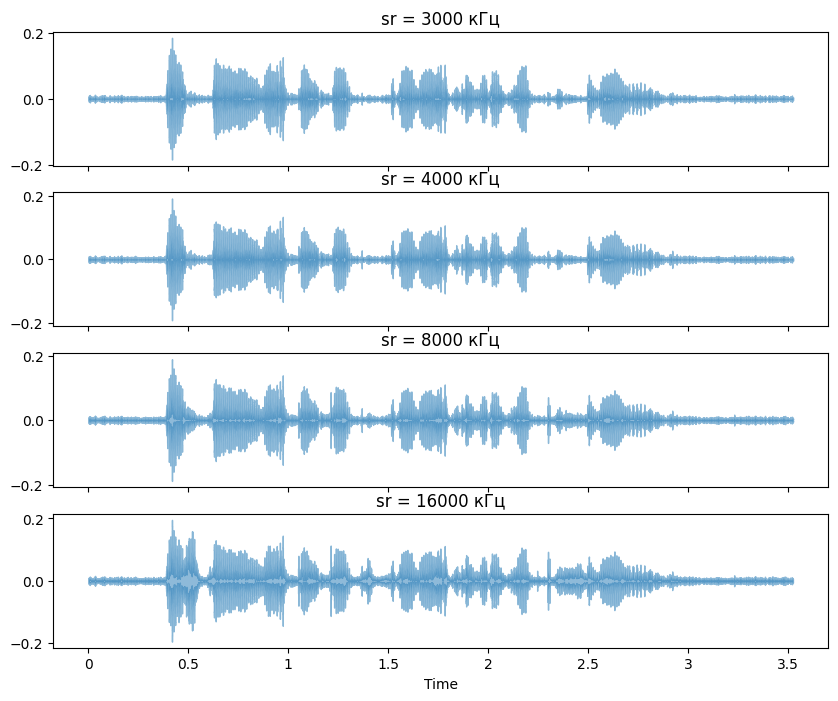

In [ ]:
# YOUR ANSWER HERE
def draw_wav(path: str) -> None:
    pairs = (librosa.load(path, sr=sample_rate) for sample_rate in (3000, 4000, 8000, 16000))
    _, ax = plt.subplots(nrows=4, sharex=True, figsize=(10, 8))
    for i, (wav, sr) in enumerate(pairs):
        print(f"Sample_rate = {sr} кГц")
        librosa.display.waveshow(wav, sr=sr, alpha=0.5, ax=ax[i])
        ax[i].set_title(f"sr = {sr} кГц")
        ax[i].set_xlabel("")
        display.display(display.Audio(wav, rate=sr, normalize=False))
    plt.xlabel("Time")


draw_wav("resources/voice.wav")

### 3. Чем .wav отличается от других кодеков, например .mp3 или .ogg?

**Ответ**

**wav:**
- Сжатие без потерь. Сохраняется как есть
- Лучше качество записи
- Больше размер

**mp3/ogg**:
- Сжатие с потерями. Перед сохранением удаляет "неважную" информацию из аудио
- Хуже качество записи, но всё ещё хорошо
- Меньше размер

# Задание 2. Гармонические сигналы (1 балл)

## Теория
[Гармонические колебания](https://ru.wikipedia.org/wiki/Гармонические_колебания) -  колебания, при которых физическая величина изменяется с течением времени по гармоническому (синусоидальному/косинусоидальному) закону. 

В общем случае гармонические колебания задаются формулой:

$$y=A \cos(\omega t+\varphi_0)$$

где $А$ - это амплитуда, $\omega$ – циклическая частота (радиан/с), $\varphi$ - фаза (сдвиг), $t$ – время. 


In [ ]:
# Сначала определим функцию для отрисовки сигнала с хорошим масштабом и сеткой
# Это поможет легче анализировать сигнал
def draw_signal(data, figsize=(13, 8)):
    plt.figure(figsize=figsize)
    plt.plot(data, linewidth=2)
    plt.minorticks_on()
    plt.xticks(np.arange(0, 1000, step=100))
    plt.yticks(
        np.arange(
            (data.min().round()) // 10 * 10,
            (data.max().round()) // 10 * 10 + 10,
            step=5,
        )
    )
    plt.grid(which="major", color="k", linewidth=1)
    plt.grid(which="minor", color="k", linestyle=":")
    plt.show()

In [ ]:
# Читаем данные с подготовленными сигналами
import pickle

with open("resources/data.pickle", "rb") as f:
    test_data = pickle.load(f)
# Теперь можно приступать к практике!

## Практика

Постройте графики трех сигналов a, b и c из test_data['task2']. Попробуйте подобрать коэффициенты для этих сигналов. Сгенерируйте сигналы (1000 отсчетов) с подобранными коэффициентами. Постройте графики сгенерированных сигналов и пройдите тест на схожесть с оригинальным.


Подсказка. Фаза, период и амплитуда сигнала - целочисленные. Для генерации пользуйтесь библиотекой numpy и функциями arange, sin, cos.

### Сигнал ***a***

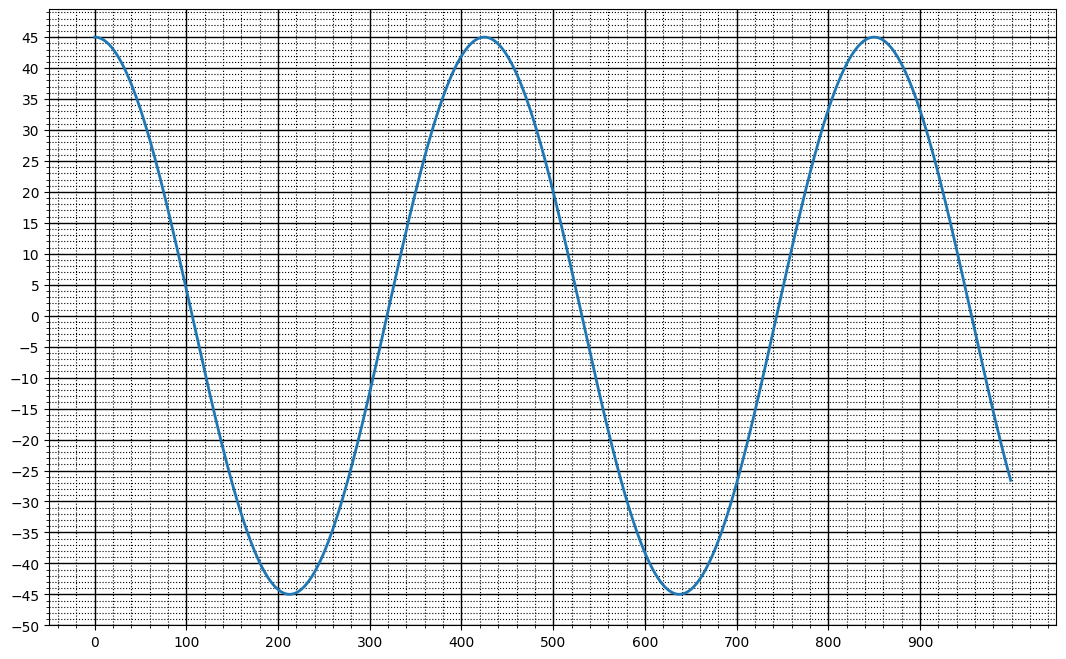

In [ ]:
draw_signal(test_data["task2"]["a"])

In [ ]:
# YOUR CODE HERE
A = 45
T = 425
omega = (2 * np.pi) / T
phi = 0
t = np.linspace(1, 1000, 1000)

a = A * np.cos(omega * t + phi)
print(f"Амплитуда: {A}, частота: {omega}, сдвиг: {phi}")

Амплитуда: 45, частота: 0.01478396542865785, сдвиг: 0


In [ ]:
# для общего развития - получение через код, а не визуальный анализ
# для общего развития - получение через код, а не визуальный анализ
def get_true(data: np.ndarray) -> tuple[int, float, int, np.ndarray]:
    A_true = int(data.max())
    occurencies = np.where(data == A_true)[0]
    T_true = occurencies[1] - occurencies[0]
    omega_true = (2 * np.pi) / T_true
    phi_true = -omega_true * t[occurencies[0]]

    a_true = A_true * np.cos(omega_true * t + phi_true)
    print(f"Амплитуда: {A_true}, частота: {omega_true}, сдвиг: {phi_true}")

    return A_true, omega_true, phi_true, a_true


A_true, omega_true, phi_true, a_true = get_true(test_data["task2"]["a"])

Амплитуда: 45, частота: 0.01478396542865785, сдвиг: -0.01478396542865785


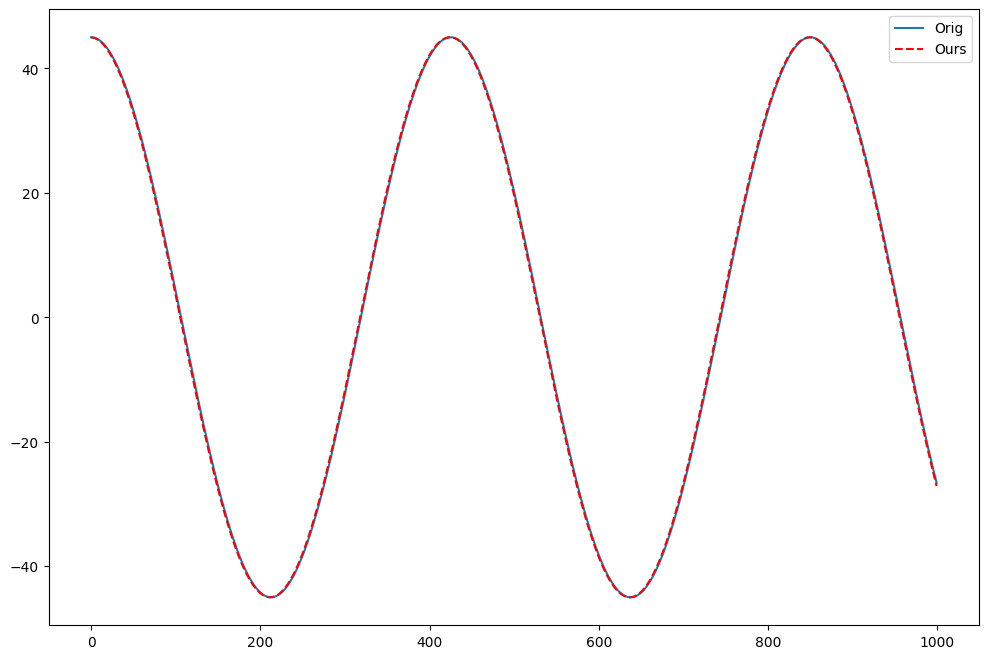

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(test_data["task2"]["a"], label="Orig")
plt.plot(a, color="red", linestyle="--", label="Ours")
plt.legend()
plt.show()

In [ ]:
assert len(a) == 1000

try:
    assert np.allclose(a, test_data["task2"]["a"], atol=1)
except AssertionError:
    assert np.allclose(a_true, test_data["task2"]["a"], atol=1)
    print("Подобранные значения разошлись на:")
    print(f"Амплитуда = {np.abs(A - A_true)}")
    print(f"Частота   = {round(np.abs(omega - omega_true), 4)}")
    print(f"Сдвиг     = {round(np.abs(phi - phi_true), 4)}")

print("Ok!")

Ok!


**Подобранные коэффициенты для сигнала 'a':**

1. Амплитуда - $A= 45$

2. Угловая частота ($ \displaystyle\omega =\frac{2\pi}{T}) \approx 0.0146$

3. Фаза - $\phi= 0$

### Сигнал ***b***

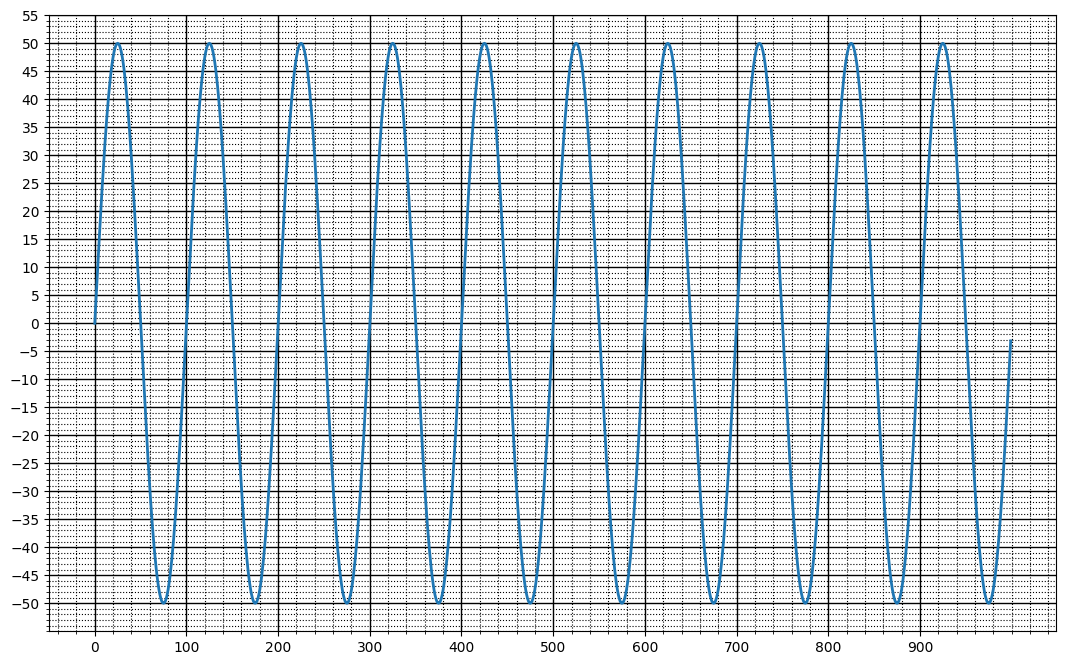

In [ ]:
draw_signal(test_data["task2"]["b"])

In [ ]:
# YOUR CODE HERE
A = 50
T = 100
omega = (2 * np.pi) / T
phi = 80

print(f"Амплитуда: {A}, частота: {omega}, сдвиг: {phi}")
b = A * np.cos(omega * t + phi)

Амплитуда: 50, частота: 0.06283185307179587, сдвиг: 80


In [ ]:
A_true, omega_true, phi_true, b_true = get_true(test_data["task2"]["b"])

Амплитуда: 50, частота: 0.06283185307179587, сдвиг: -1.6336281798666925


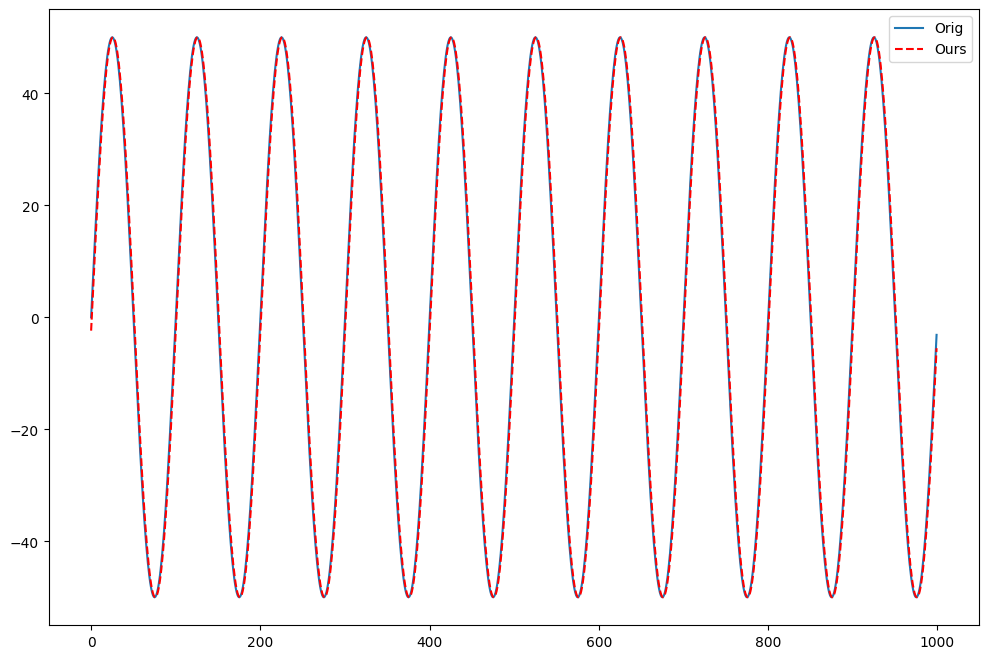

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(test_data["task2"]["b"], label="Orig")
plt.plot(b, color="red", linestyle="--", label="Ours")
plt.legend()
plt.show()

In [ ]:
assert len(b) == 1000

try:
    assert np.allclose(b, test_data["task2"]["b"], atol=1)
except AssertionError:
    assert np.allclose(b_true, test_data["task2"]["b"], atol=1)
    print("Подобранные значения разошлись на:")
    print(f"Амплитуда = {np.abs(A - A_true)}")
    print(f"Частота   = {round(np.abs(omega - omega_true), 4)}")
    print(f"Сдвиг     = {round(np.abs(phi - phi_true), 4)}")
print("Ok!")

Подобранные значения разошлись на:
Амплитуда = 0
Частота   = 0.0
Сдвиг     = 81.6336
Ok!


**Подобранные коэффициенты для сигнала 'b':**

1. Амплитуда - $A= 50$

2. Угловая частота ($ \displaystyle\omega =\frac{2\pi}{T}) = 0.0628$

3. Фаза - $\phi= 80$

### Сигнал ***c***

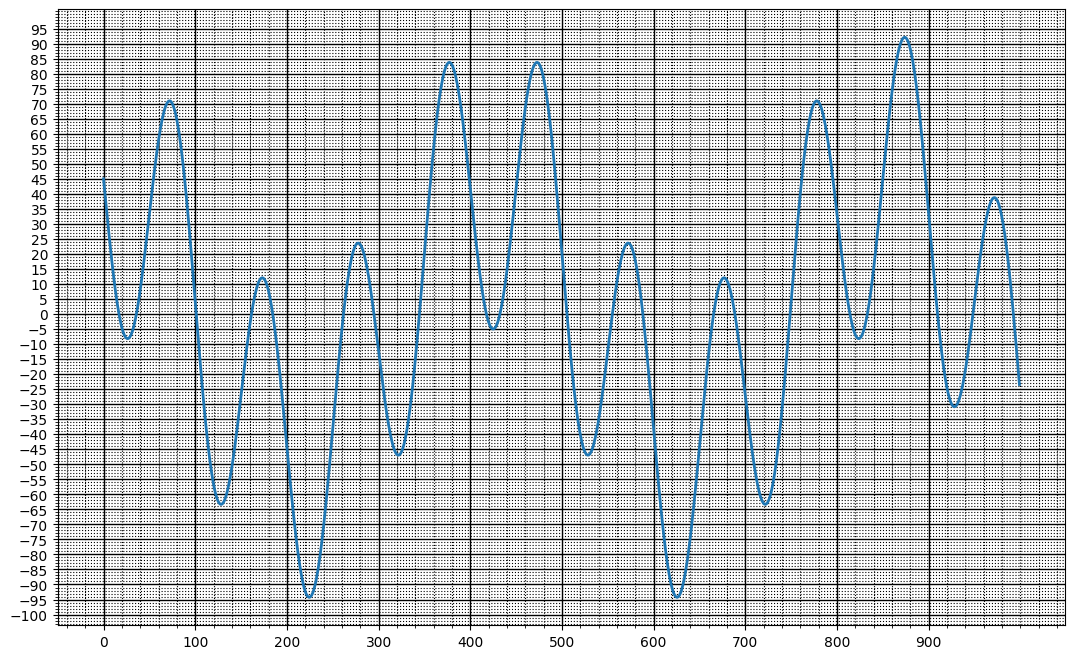

In [ ]:
draw_signal(test_data["task2"]["c"])

In [ ]:
fft = np.fft.rfft(test_data["task2"]["c"])  # делаем FFT для получения магнитуд
frequencies = np.fft.rfftfreq(len(test_data["task2"]["c"]), d=1)  # получаем частоты

# получение и нормировка магнитуд
magnitudes = 2 * np.abs(fft) / len(test_data["task2"]["c"])

# получаем индексы с нашими чстотами
peaks_indices = (-magnitudes).argsort()[:2]

signals = {"A": [0, 0], "omega": [0, 0], "phi": [0, 0]}
for i, idx in enumerate(peaks_indices):
    signals["A"][i] = magnitudes[idx]  # амплитуда
    signals["omega"][i] = 2 * np.pi * frequencies[idx]  # частота
    signals["phi"][i] = np.angle(fft[idx])  # сдвиг

    print("Функция", i + 1)
    print(f"Амплитуда: {round(signals['A'][i], 4)}")
    print(f"Частота: {round(signals['omega'][i], 4)}")
    print(f"Сдвиг: {round(signals['phi'][i], 4)}")
    print("_" * 10)

Функция 1
Амплитуда: 47.5711
Частота: 0.0628
Сдвиг: 1.5753
__________
Функция 2
Амплитуда: 34.6711
Частота: 0.0126
Сдвиг: 1.0391
__________


In [ ]:
# YOUR CODE HERE
A1 = signals["A"][0]
omega1 = signals["omega"][0]
phi1 = signals["phi"][0]

A2 = signals["A"][1]
omega2 = signals["omega"][1]
phi2 = signals["phi"][1]

c_fft = A1 * np.cos(omega1 * t + phi1) + A2 * np.cos(omega2 * t + phi2)

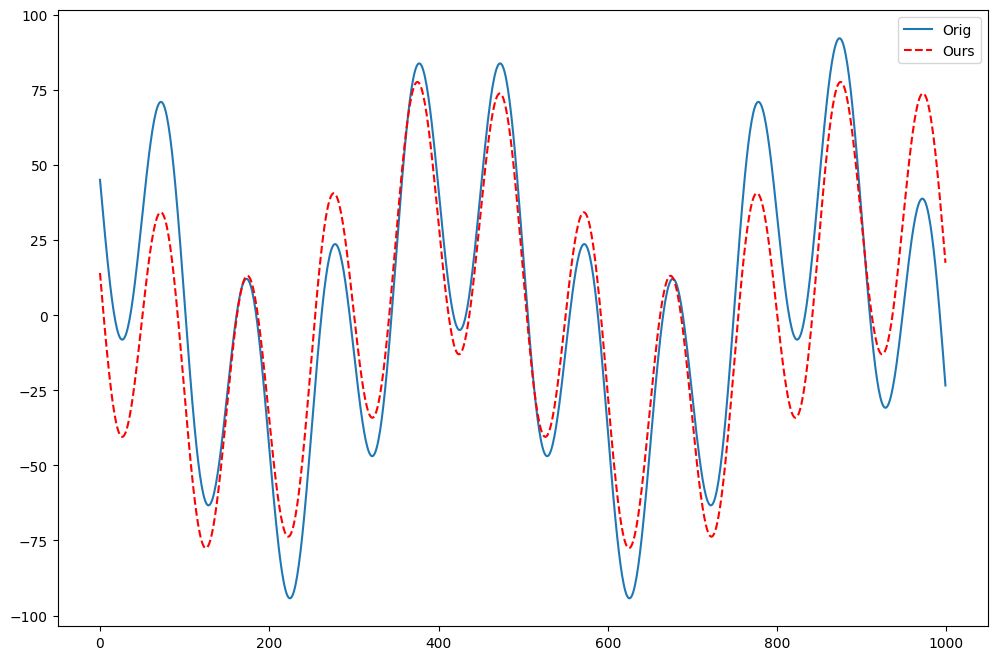

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(test_data["task2"]["c"], label="Orig")
plt.plot(c_fft, color="red", linestyle="--", label="Ours")
plt.legend()
plt.show()

Так, теперь ручками

На графике **с** видно, что у первого период в 100, у второго около 400-500

У более частой амплитуда где-то около 40 (видно на моменте падения на верхнем пике), у второго около 30

После перебора - лучшая попытка

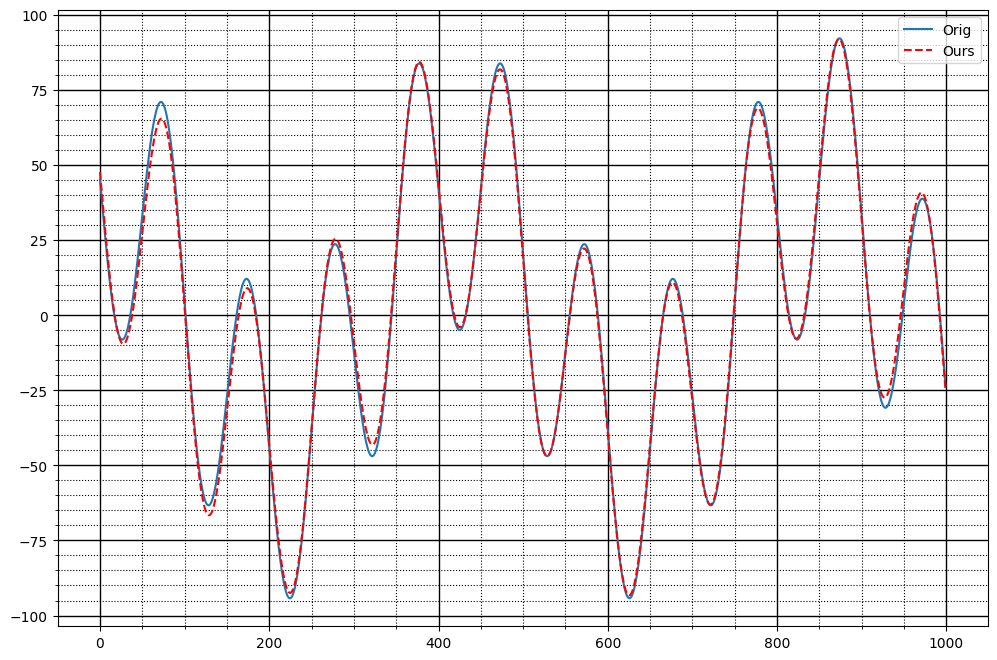

In [ ]:
# YOUR CODE HERE
A1 = 49
omega1 = 2 * np.pi / 99.8
phi1 = 1.45

A2 = 45
omega2 = 2 * np.pi / 430
phi2 = 0.1

c = A1 * np.cos(omega1 * t + phi1) + A2 * np.cos(omega2 * t + phi2)

plt.figure(figsize=(12, 8))
plt.plot(test_data["task2"]["c"], label="Orig")
plt.plot(c, color="red", linestyle="--", label="Ours")
plt.legend()
plt.minorticks_on()
plt.grid(which="major", color="k", linewidth=1)
plt.grid(which="minor", color="k", linestyle=":")
plt.show()

~~Не удалось полностью приблизиться к реальному сигналу, поэтому Assert тактично закомментирован~~

После ручного подбора заметил, что значения близки к **a** и **b**, поэтому решил проверить

Амплитуда: 50, частота: 0.06283185307179587, сдвиг: -1.6336281798666925


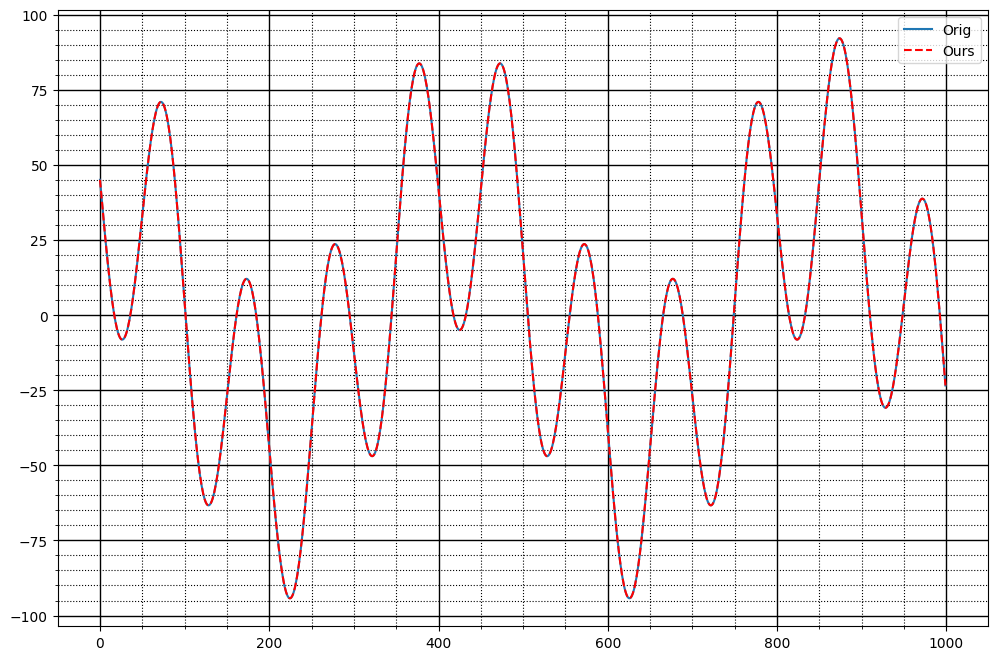

In [ ]:
A_true, omega_true, phi_true, _ = get_true(test_data["task2"]["b"])
b_phased = A_true * np.cos(omega_true * t + phi_true + np.pi)
c_true = a_true + b_phased

plt.figure(figsize=(12, 8))
plt.plot(test_data["task2"]["c"], label="Orig")
plt.plot(c_true, color="red", linestyle="--", label="Ours")
plt.legend()
plt.minorticks_on()
plt.grid(which="major", color="k", linewidth=1)
plt.grid(which="minor", color="k", linestyle=":")
plt.show()

In [ ]:
assert len(c) == 1000
assert np.allclose(c_true, test_data["task2"]["c"], atol=1)
print("Ok!")

Ok!


# Задание 3. Свертка (3 балла)

## Теория
Одна из наиболее частых операций, которая выполняется при обработке сигналов, это свёртка. Свёртка имеет много различных применений, например, с ее помощью можно убрать из сигнала шумы или применить к сигналу эффект эхо.


Свёртка — это математическая операция, применённая к двум функциям f и g и порождающая третью функцию. Операцию свёртки можно интерпретировать как «схожесть» одной функции с отражённой и сдвинутой копией другой.  Другими словами, преобразование свёртки однозначно определяет выходной сигнал y(t) для установленного значения входного сигнала x(t) при известном значении функции импульсного отклика системы h(t).

<!-- ![Convolution](resources/Convolution_of_box_signal_with_itself2.gif "Convolution") -->
![Convolution](resources/Convolution_of_box_signal_with_itself2.gif "Convolution")

Формула свёртки:
$$y_t=\frac{1}{2} \int_0^T x(\tau)h(t-τ)dτ$$
где $\tau$  - длительность импульсной переходной характеристики.

## Практика
Реализуйте операцию свёртки. Сравните её с существующей реализацией scipy.signal.convolve. Постройте графики фильтра, исходного сигнала и результата свертки.

In [ ]:
def convolve(in1: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    # YOUR CODE HERE
    conv_size = in1.shape[0] + kernel.shape[0] - 1
    res = np.zeros(conv_size)
    for i in range(conv_size):
        # чтобы не сильно  париться паддингом
        for j in range(max(0, i - in1.shape[0] + 1), min(kernel.shape[0], i + 1)):
            res[i] += in1[i - j] * kernel[j]
    return res

In [ ]:
def test_convolve(a, b, print_debug=False):
    my_result = convolve(a, b)
    scipy_result = scipy.signal.convolve(a, b, method="direct")
    if print_debug:
        print(f"Your result {my_result}")
        print(f"Scipy result {scipy_result}")
    assert np.allclose(my_result, scipy_result), f"Test {a} conv {b} failed"
    print("Ok!")

In [ ]:
a = np.repeat([0, 1, 0], 10)
b = np.array([0, 1, 2, 3, 2, 1, 0])

In [ ]:
test_convolve(a, b, print_debug=False)

Ok!


### Нарисуйте результат свертки a и b

Сигнал **а**

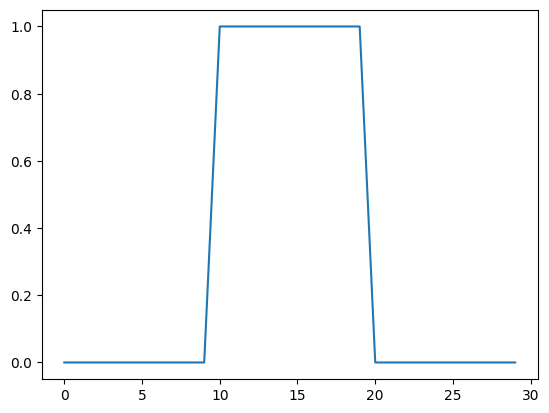

In [ ]:
# YOUR CODE HERE
plt.plot(a)
plt.show()

Сигнал **b**

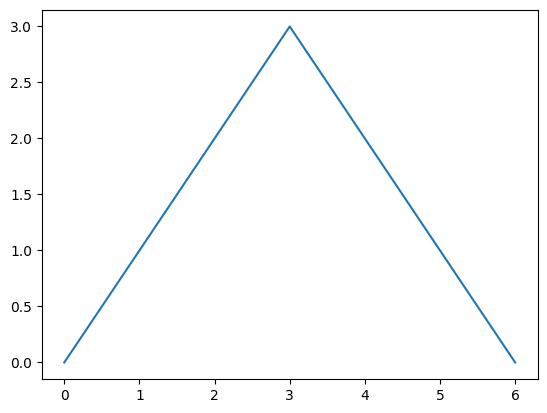

In [ ]:
# YOUR CODE HERE
plt.plot(b)
plt.show()

Свертка **a** и **b**

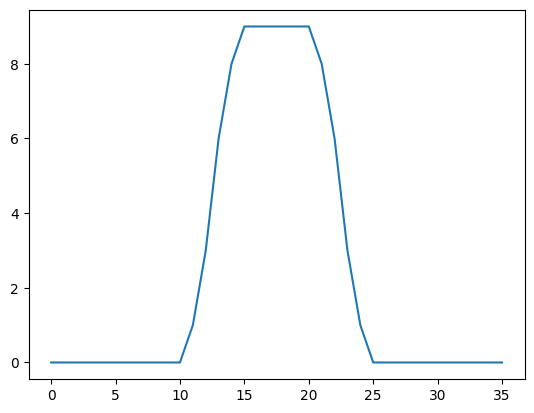

In [ ]:
# YOUR CODE HERE
plt.plot(convolve(a, b))
plt.show()

Все 3 графика на одной картинке:

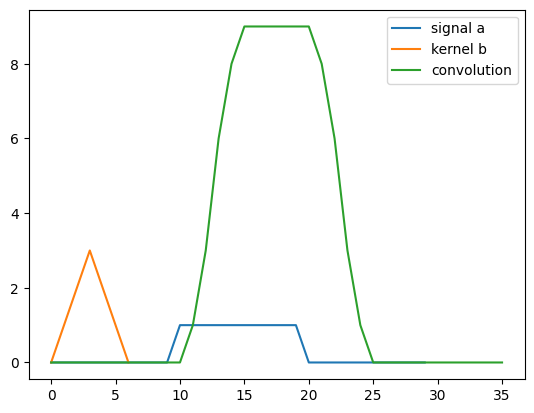

In [ ]:
# YOUR CODE HERE
plt.plot(a, label="signal a")
plt.plot(b, label="kernel b")
plt.plot(convolve(a, b), label="convolution")
plt.legend()
plt.show()

# Задание 4. * Алгоритм Карплуса-Стронга 

Реализуйте  [Алгоритм Карплуса-Стронга](https://en.wikipedia.org/wiki/Karplus%E2%80%93Strong_string_synthesis). В качестве фильтра используйте усреднитель двух смежных отсчетов. Проверьте результат. 

Отрисуйте и воспроизведите полученный сигнал. На что влияют параметры генерации? Попробуйте имитировать звучание разных струн гитары.

In [ ]:
def karplus_strong(noise: np.ndarray, N: int) -> np.ndarray:
    # Noise - input
    # N - number of samples to generate
    # return y - generated signal based on Noise
    # YOUR CODE HERE
    noise_size = noise.shape[0]
    music = np.pad(noise, (0, N - noise_size), mode="constant", constant_values=0)

    for i in range(noise_size, N):
        music[i] = (music[i - noise_size] + music[i - noise_size - 1]) / 2

    return music

In [ ]:
np.random.seed(seed=1)
sample_rate = 44100
frequency = 82.41
sec = 2
gen_len = sample_rate * sec
noise = 2 * np.random.uniform(-1, 1, int(sample_rate / frequency))  # [-1, 1]

gen_wav = karplus_strong(noise, gen_len)
assert np.allclose(gen_wav[: len(noise)], noise), "Generated signal must starting with noise"
assert np.allclose(gen_wav[len(noise)], (noise[0]) / 2), "Out of range samples eq 0."
assert np.allclose(gen_wav[len(noise) + 1 : 2 * len(noise)], (noise[:-1] + noise[1:]) / 2), (
    "Bad requrent rule( 1 iteration)"
)
assert np.allclose(gen_wav[2 * len(noise)], (noise[0] / 2 + noise[-1]) / 2), "Bad requrent rule( 2 iteration)"
assert np.allclose(
    gen_wav[2 * len(noise) + 2 : 3 * len(noise)],
    (((noise[:-1] + noise[1:]) / 2)[:-1] + ((noise[:-1] + noise[1:]) / 2)[1:]) / 2,
), "Bad requrent rule( 3 iteration)"
print("All Ok!")
display.display(display.Audio(gen_wav, rate=sample_rate))

All Ok!


### Попробуем покрутить параметры генерации

Сгенерируем гитарные ноты:

In [ ]:
# YOUR CODE HERE
notes = []

for i in range(3):
    note = f"A{i + 1}"
    noise = 2 * np.random.uniform(-1, 1, int(librosa.note_to_hz(note)))
    gen_wav = karplus_strong(noise, gen_len)
    notes.append(gen_wav)
    print(note)
    display.display(display.Audio(gen_wav, rate=sample_rate))

A1


A2


A3


Визуализируем затухание амплитуды:

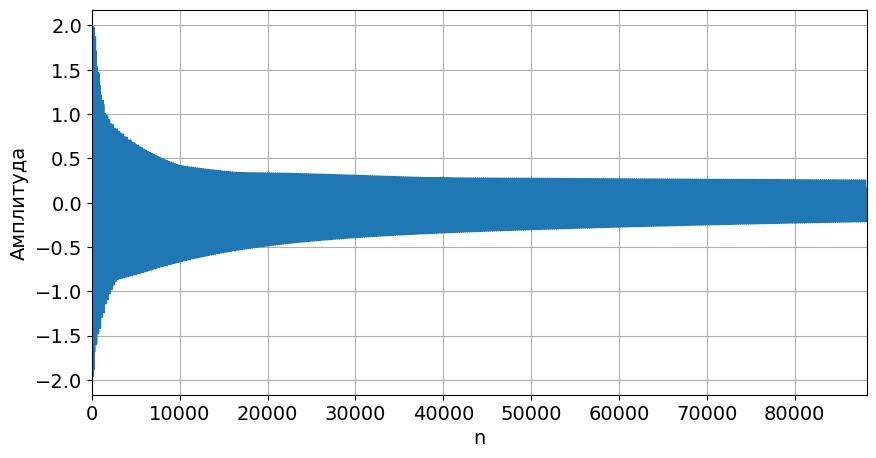

In [ ]:
plt.figure(figsize=(10, 5))
plt.xlabel("n", fontsize=14)
plt.ylabel("Амплитуда", fontsize=14)
plt.xlim(0, gen_len)
plt.plot(np.linspace(0, gen_len + 1, gen_len), gen_wav)
plt.tick_params(axis="both", which="major", labelsize=14)
plt.grid()

Визуализируйте затухание амплитуд гитарных нот:

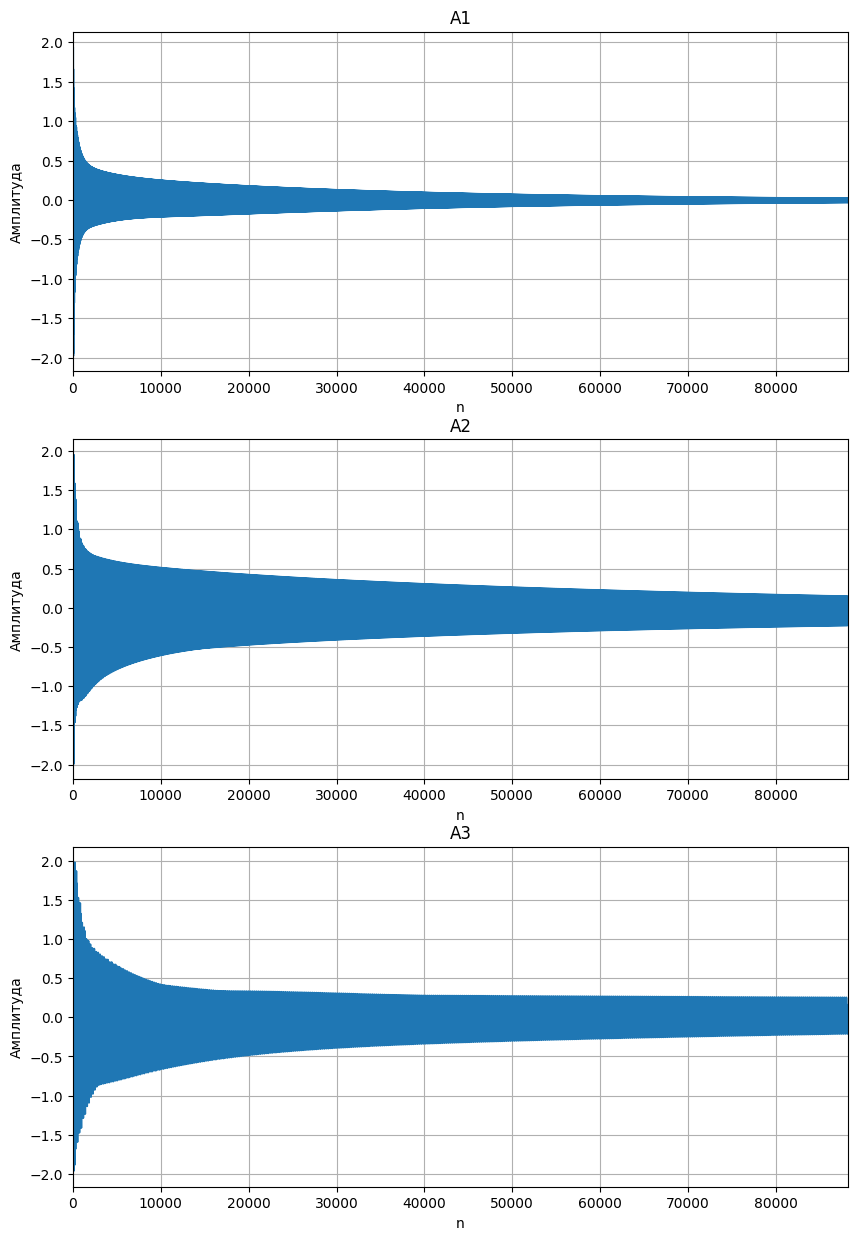

In [ ]:
# YOUR CODE HERE
fig, ax = plt.subplots(nrows=len(notes), figsize=(10, 5 * len(notes)))
for i in range(len(notes)):
    ax[i].set_xlim(0, gen_len)
    ax[i].plot(np.linspace(0, gen_len + 1, gen_len), notes[i])
    ax[i].tick_params(axis="both", which="major", labelsize=10)
    ax[i].grid()
    ax[i].set_title(f"A{i + 1}", fontsize=12)
    ax[i].set_xlabel("n", fontsize=10)
    ax[i].set_ylabel("Амплитуда", fontsize=10)